In [ ]:
# Day 3: Image Preprocessing Fundamentals
# Covers: Resizing,
#  Color Space Conversion,
#  Thresholding, Morphological Operations —
#   the core preprocessing pipeline before detection.

In [ ]:
!pip install -q ultralytics

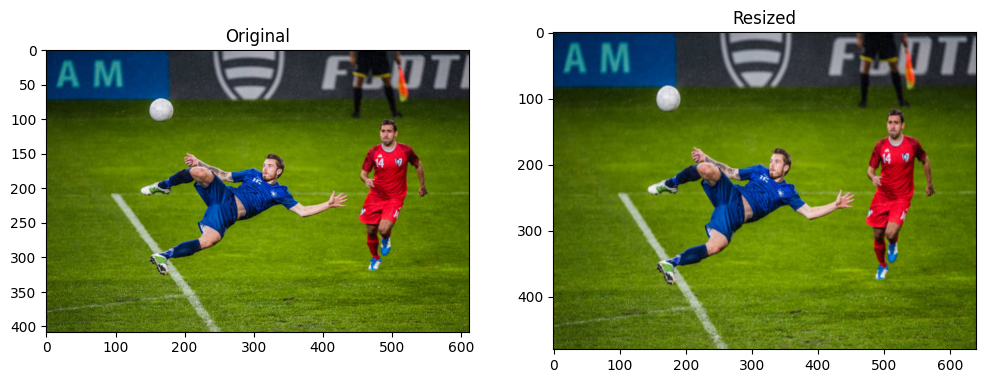

In [ ]:
# Q1:
# Load your football match image
# (the one you used on Day 2). Resize it to 640×480 using
# cv2.INTER_LINEAR interpolation.
# Display both the original and resized images side-by-side
# with plt.subplots() to show the scaling.

# Function Hint:
# cv2.resize()
# That's it. Write the complete code — image loading, resizing with
# correct parameters, and matplotlib display. Consult OpenCV docs for the exact syntax.

import matplotlib.pyplot as plt

import cv2
# Convert BGR to RGB for matplotlib display
img = cv2.imread("/content/football image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resize_img_rgb = cv2.cvtColor(resize_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Display on axes[0] and axes[1], not plt.imshow()
axes[0].imshow(img_rgb)
axes[0].set_title("Original")

axes[1].imshow(resize_img_rgb)
axes[1].set_title("Resized")

plt.show()  # Only ONCE at the end

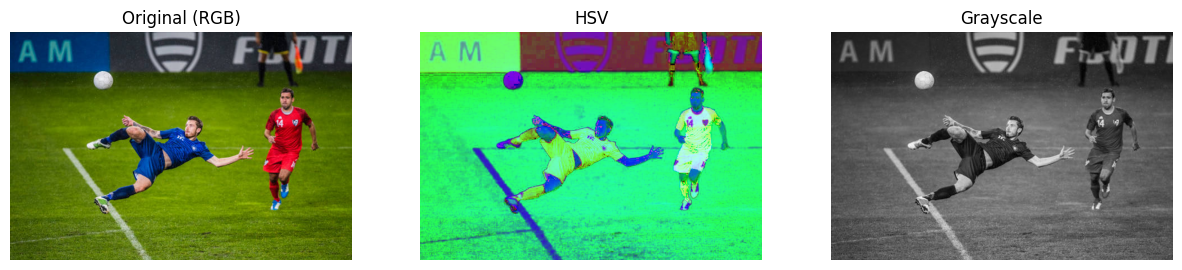

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the image
img = cv2.imread("/content/football image.jpg")

# 2. Convert color spaces (Fixing the 'GRAY' typo)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      # For correct matplotlib display
con_HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
con_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)    # Use 'GRAY', not 'GREY'

# 3. Create a 1x3 grid layout
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Original (RGB)
axes[0].imshow(img_rgb)
axes[0].set_title("Original (RGB)")
axes[0].axis('off')

# Plot HSV
axes[1].imshow(con_HSV)
axes[1].set_title("HSV")
axes[1].axis('off')

# Plot Grayscale (Moving cmap='gray' to imshow)
axes[2].imshow(con_gray, cmap="gray")
axes[2].set_title("Grayscale")
axes[2].axis('off')

# 4. Display all at once
plt.tight_layout()
plt.show()

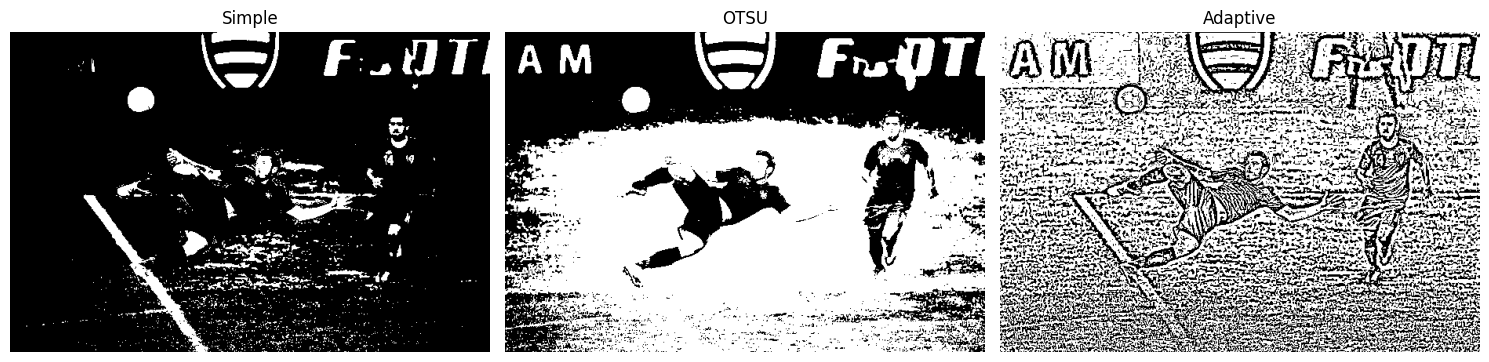

In [ ]:
# # Day 3, Question 3: Thresholding
# # Concept:
# # Convert your grayscale image to binary (black/white only).
#  Useful for separating objects from background.
# # Three types:

# # Simple threshold — fixed cutoff (e.g., pixel ≥ 127 → white, else black)
# # Otsu's threshold — automatic optimal cutoff (no guessing)
# # Adaptive threshold — adjusts locally for each region (handles shadows/uneven lighting)


# # Task:
# # Using your grayscale image from Q2:

# # Apply simple threshold with value 127
# # Apply Otsu's threshold (automatic)
# # Apply adaptive threshold (method: ADAPTIVE_THRESH_GAUSSIAN_C,
#  block size: 11, constant: 2)
# # Display all three in a 1×3 grid


# # Function Hint:
# # cv2.threshold()
# # That's it. Look up the flags and parameters in OpenCV docs.
# You'll need different flags for simple vs Otsu vs adaptive.


import cv2
import matplotlib.pyplot as plt


img = cv2.imread("/content/football image.jpg")
con_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

ret1,sim_threh1 = cv2.threshold(con_gray,127,255,cv2.THRESH_BINARY)

ret2,otsu_thresh2= cv2.threshold(con_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

adaptive_thresh = cv2.adaptiveThreshold(con_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)


#adaptive_threshold = cv2.threshold(con_gray,)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#simple

axes[0].imshow(sim_threh1,cmap="gray")
axes[0].set_title("Simple")
axes[0].axis("off")

#Otsus

axes[1].imshow(otsu_thresh2,cmap="gray")
axes[1].set_title("OTSU")
axes[1].axis("off")

#Adaptive
axes[2].imshow(adaptive_thresh,cmap="gray")
axes[2].set_title("Adaptive")
axes[2].axis("off")

#show
plt.tight_layout()
plt.show()

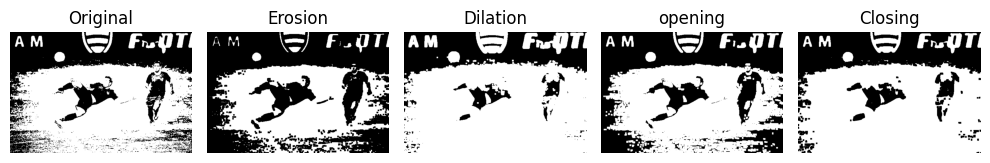

In [ ]:
# Question 4: Morphological Operations
# Concept:
# Clean up binary images. Erosion shrinks white regions (removes noise).
#  Dilation expands them (fills holes). Combine them:

# Opening = Erosion → Dilation. Removes small noise, keeps large objects.
# Closing = Dilation → Erosion. Fills interior holes, keeps object shape.


# Task:
# Using the Otsu thresholded image from Q3:

# Apply Erosion (kernel size 5×5)
# Apply Dilation (kernel size 5×5)
# Apply Opening (kernel size 5×5)
# Apply Closing (kernel size 5×5)
# Display all five in a 1×5 grid: Original Otsu binary, Erosion, Dilation, Opening, Closing


# Function Hints:

# cv2.getStructuringElement() — create kernel
# cv2.erode()
# cv2.dilate()
# cv2.morphologyEx() — for opening/closing


import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/football image.jpg")
con_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret2,otsu_img = cv2.threshold(con_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

kernal = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
ero = cv2.erode(otsu_img,kernal,iterations = 1)
dil = cv2.dilate(otsu_img,kernal,iterations = 1)
opening = cv2.morphologyEx(otsu_img,cv2.MORPH_OPEN,kernal)
closing = cv2.morphologyEx(otsu_img,cv2.MORPH_CLOSE,kernal)

fig,axes = plt.subplots(1,5,figsize=(10,5))

#Otsu_img
axes[0].imshow(otsu_img,cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

#Eroison
axes[1].imshow(ero,cmap="gray")
axes[1].set_title("Erosion")
axes[1].axis("off")

#Dilation
axes[2].imshow(dil,cmap="gray")
axes[2].set_title("Dilation")
axes[2].axis("off")

#Opening
axes[3].imshow(opening,cmap="gray")
axes[3].set_title("opening")
axes[3].axis("off")

#closing
axes[4].imshow(closing,cmap="gray")
axes[4].set_title("Closing")
axes[4].axis("off")


#showing
plt.tight_layout()
plt.show()